In [1]:

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
!nvidia-smi
import numpy as np
from collections import namedtuple, deque
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import gym
import math
import random
import matplotlib
import matplotlib.pyplot as plt



Fri Nov  3 21:35:32 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 520.61.05    Driver Version: 520.61.05    CUDA Version: 11.8     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  NVIDIA GeForce ...  On   | 00000000:05:00.0 Off |                  N/A |
|  0%   30C    P8    13W / 198W |      1MiB /  8192MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   1  NVIDIA GeForce ...  On   | 00000000:06:00.0 Off |                  N/A |
| 27%   

In [2]:
env = gym.make('MsPacman-v0')

mspacman_color = 210 + 164 + 74
def preprocess_observation(obs):
    img = obs[1:176:2, ::2] # crop and downsize
    img = img.sum(axis=2) # to greyscale
    img[img==mspacman_color] = 0 # Improve contrast
    img = (img // 3 - 128).astype(np.int8) # normalize from -128 to 127
    return img.reshape(88, 80, 1)



batch_size = 256
gamma = 0.99
eps_max = 0.9
eps_min = 0.05
eps_decay = 1000
taw = 0.005
LR = 0.0001
capacity = 100000

#Namedtuple allows us to save eah tuple as a class, where its elements are
#objects with names, which makes accessing elements easier.
Tuple_tobesaved = namedtuple('Transition',('state', 'action', 'next_state', 'reward'))

class buildDQN(nn.Module):
    def __init__(self, state_size, actions_num):
        super(buildDQN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=4, stride=2)
        self.conv2 = nn.Conv2d(16,8, kernel_size=3, stride=1)
        self.fc1 = nn.Linear(12136, 32)
        self.fc2 = nn.Linear(32, actions_num)

    def forward(self, x):
        #print(x.shape)
        x = torch.relu(self.conv1(x))
        #print(x.shape)
        x = torch.relu(self.conv2(x))
        #print(x.shape)
        x = x.reshape(x.size(0), -1)  # Flatten the input
        #print(x.shape)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

        '''
        self.layer1 = nn.Linear(state_size, 128)
        nn.init.kaiming_normal_(self.layer1.weight, nonlinearity='relu')
        self.layer2 = nn.Linear(128, 128)
        nn.init.kaiming_normal_(self.layer2.weight, nonlinearity='relu')
        self.layer3 = nn.Linear(128, actions_num)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        x = self.layer3(x)
        return x
        '''



class ReplayBuffer(object):

    def __init__(self, capacity):
        #initiate max capacity
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        #add tuples
        self.memory.append(Tuple_tobesaved(*args))

    def sample(self, batch_size):
        #sample tuples at random
        return random.sample(self.memory, batch_size)

    def len(self):
        #check the length of the buffer
        return len(self.memory)

actions_num = env.action_space.n
state, info = env.reset()
state_size = len(state)
#but we will be reshaing the state to (88,80,1)

policy_net = buildDQN((1, 88, 80), actions_num)
target_net = buildDQN((1, 88, 80), actions_num)
target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.AdamW(policy_net.parameters(), lr=LR, amsgrad=True)
memory = ReplayBuffer(capacity)


steps_done = 0


def select_action(state):
    global steps_done
    sample = random.random()
    #exponential decay
    eps_threshold = eps_min + (eps_max - eps_min) * math.exp(-1. * steps_done / eps_decay)
    action1 =  torch.tensor([[env.action_space.sample()]],  dtype=torch.long)
    with torch.no_grad():
        #tuple_Q_a return the tuple of max Q and its corresponding index
        tuple_Q_a = policy_net(state).max(1)
        action2 = tuple_Q_a[1].view(1, 1)
        Qmax = tuple_Q_a[0]
    steps_done += 1
    if sample <= eps_threshold:
        return [action1, Qmax]
    else:
        return [action2, Qmax]



episode_rewards = []
Qmax_episodes = []

def update_networks():
    if memory.len() < batch_size:
        return
    #sample a minimbatch from the replay buffer at random
    transitions = memory.sample(batch_size)

    #zip all tuples together of the minibatch
    batch = Tuple_tobesaved(*zip(*transitions))

    # yi differs between states that are the last in an episode and states that are not
    # for this reason a mask is created to track which ones are final states and which ones arenot
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None, batch.next_state)),  dtype=torch.bool)
    #collecting states that are not final states based on the mask
    non_final_next_states = torch.cat([s for s in batch.next_state if s is not None])

    #collecting the states, actions, and rewards in one tensor each
    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    #Get the Q values of the states in the minibatch
    state_action_values = policy_net(state_batch).gather(1, action_batch)


    # Get targets based on states of minibatch
    #all states are initiated to zero
    next_state_values = torch.zeros(batch_size)
    with torch.no_grad():
        #the states that are not the last are replaced by the target
        next_state_values[non_final_mask] = target_net(non_final_next_states).max(1)[0]
    # Compute the expected yi values
    #multipled by gamma and add the reward. The last states will only have yi=reward
    expected_state_action_values = (next_state_values * gamma) + reward_batch

    # Using huber loss only, as recommended in the lecture.
    #Smooth L1 loss is closely related to HuberLoss
    #https://pytorch.org/docs/stable/generated/torch.nn.SmoothL1Loss.html
    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

    # Optimize the model using backpropagation
    optimizer.zero_grad()
    loss.backward()
    # gradient clipping
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
    optimizer.step()

    
###Load model, np array before interruptions
file_path1 = 'np_eps_rewards_Mspacman3050_.npy'
episode_rewards = np.load(file_path1 ).tolist()
file_path2 = 'Qmax_episodes_nps_Mspacman_3050_.npy'
Qmax_episodes = np.load(file_path2 ).tolist()

policy_net = torch.load('policy_net_MsPacman_3050_.pth')
target_net = torch.load('target_net_MsPacman_3050_.pth')


/nfs/home/dem1110/.conda/envs/mldsrl/lib/python3.8/site-packages/gym/envs/registration.py:555: UserWarning: WARN: The environment MsPacman-v0 is out of date. You should consider upgrading to version `v4`.
  logger.warn(
A.L.E: Arcade Learning Environment (version 0.8.1+53f58b7)
[Powered by Stella]


In [5]:
"""# Testing the model"""

num_episodes = 500
Sample_Episodes = []
for episode in range(num_episodes):
    state, info = env.reset()
    state = preprocess_observation(state)
    state = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
    state = state.permute(0, 3, 1, 2)
    
    total_reward = 0
    done = False
    terminated=False
    truncated =False
    while (not terminated) and (not truncated):
        action = policy_net(state).max(1)[1].view(1, 1)
        observation, reward, terminated, truncated, info = env.step(action.item())
        reward = torch.tensor([reward])
        done = terminated or truncated
        # Move to the next state
        observation = preprocess_observation(observation)
        state = torch.tensor(observation, dtype=torch.float32).unsqueeze(0)
        state = state.permute(0, 3, 1, 2)
        total_reward+=reward

    Sample_Episodes.append(float(total_reward))
    print(f"Episode: {episode}, Reward: {float(total_reward)}")
np_eps_rewards_Sample = np.array(Sample_Episodes)
np.save('sample500_np_eps_rewards_Mspacman.npy', np_eps_rewards_Sample)



Episode: 0, Reward: 1280.0
Episode: 1, Reward: 1280.0
Episode: 2, Reward: 840.0
Episode: 3, Reward: 1250.0
Episode: 4, Reward: 980.0
Episode: 5, Reward: 770.0
Episode: 6, Reward: 1460.0
Episode: 7, Reward: 1480.0
Episode: 8, Reward: 990.0
Episode: 9, Reward: 760.0
Episode: 10, Reward: 1460.0
Episode: 11, Reward: 770.0
Episode: 12, Reward: 1340.0
Episode: 13, Reward: 1170.0
Episode: 14, Reward: 750.0
Episode: 15, Reward: 890.0
Episode: 16, Reward: 700.0
Episode: 17, Reward: 610.0
Episode: 18, Reward: 1250.0
Episode: 19, Reward: 680.0
Episode: 20, Reward: 1530.0
Episode: 21, Reward: 1370.0
Episode: 22, Reward: 980.0
Episode: 23, Reward: 1630.0
Episode: 24, Reward: 920.0
Episode: 25, Reward: 550.0
Episode: 26, Reward: 1010.0
Episode: 27, Reward: 1260.0
Episode: 28, Reward: 1890.0
Episode: 29, Reward: 660.0
Episode: 30, Reward: 940.0
Episode: 31, Reward: 910.0
Episode: 32, Reward: 800.0
Episode: 33, Reward: 1180.0
Episode: 34, Reward: 1130.0
Episode: 35, Reward: 1080.0
Episode: 36, Reward:

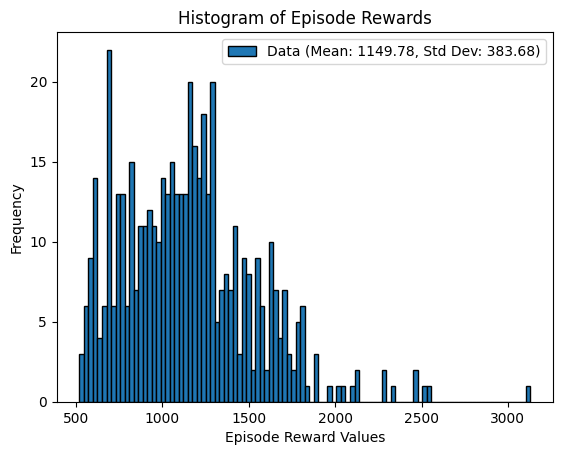

In [11]:
#numpy_array = np.array([tensor.numpy() for tensor in Sample_Episodes])
numpy_array = np.array(Sample_Episodes)
mean = np.mean(numpy_array)
std_dev = np.std(numpy_array)

legend_label = f'Data (Mean: {mean:.2f}, Std Dev: {std_dev:.2f})'
plt.figure()
plt.hist(Sample_Episodes, bins=100,edgecolor='black')
plt.xlabel('Episode Reward Values')
plt.ylabel('Frequency')
plt.legend([legend_label])
plt.title('Histogram of Episode Rewards')
#plt.show()
plt.savefig('Histogramof500episodes_MsPacman_100bins_withedge.png')